#🛠️ Preparação dos Dados

## Bibliotecas Base Utilizadas

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

## Extração do Arquivo Tratado

In [2]:
dados_tratados = pd.read_csv('/content/dados_tratados.csv')

In [3]:
dados_tratados.head()

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total,customer.SeniorCitizen_cat
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30,Não idoso
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40,Não idoso
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85,Não idoso
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85,Idoso
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40,Idoso


In [4]:
dados_tratados.shape

(7043, 22)

## Remoção de Colunas Irrelevantes

In [5]:
dados_tratados = dados_tratados.drop(columns=['customerID', 'customer.SeniorCitizen_cat'])

## Encoding

In [6]:
dados_tratados["customer.gender"] = dados_tratados["customer.gender"].map({
    "Female": 1,
    "Male": 0
})

In [7]:
# Converter target
dados_tratados["Churn"] = dados_tratados["Churn"].map({
    "Yes": 1,
    "No": 0
})

In [8]:
# Converter binárias

colunas_binarias = [
    "customer.Partner",
    "customer.Dependents",
    "phone.PhoneService",
    "account.PaperlessBilling"
]

for col in colunas_binarias:
    dados_tratados[col] = dados_tratados[col].map({
        "Yes": 1,
        "No": 0
    })

In [9]:
# OHE para variáveis multicategóricas

colunas_multicategoricas = [
    "internet.InternetService",
    "account.Contract",
    "account.PaymentMethod",
    "internet.OnlineSecurity",
    "internet.OnlineBackup",
    "internet.DeviceProtection",
    "internet.TechSupport",
    "internet.StreamingTV",
    "internet.StreamingMovies",
    "phone.MultipleLines"
]

dados_tratados = pd.get_dummies(
    dados_tratados,
    columns=colunas_multicategoricas,
    drop_first=False  # manter todas para análise de correlação
)

In [10]:
dados_tratados.head()

,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,account.PaperlessBilling,account.Charges.Monthly,account.Charges.Total,...,internet.DeviceProtection_No,internet.DeviceProtection_Yes,internet.TechSupport_No,internet.TechSupport_Yes,internet.StreamingTV_No,internet.StreamingTV_Yes,internet.StreamingMovies_No,internet.StreamingMovies_Yes,phone.MultipleLines_No,phone.MultipleLines_Yes
0,0,1,0,1,1,9,1,1,65.6,593.30,...,True,False,False,True,False,True,True,False,True,False
1,0,0,0,0,0,9,1,0,59.9,542.40,...,True,False,True,False,True,False,False,True,False,True
2,1,0,0,0,0,4,1,1,73.9,280.85,...,False,True,True,False,True,False,True,False,True,False
3,1,0,1,1,0,13,1,1,98.0,1237.85,...,False,True,True,False,False,True,False,True,True,False
4,1,1,1,1,0,3,1,1,83.9,267.40,...,True,False,False,True,False,True,True,False,True,False


## Verificação da Proporção de Evasão

In [11]:
dados_tratados["Churn"].value_counts(normalize=True)

,proportion
Churn,
0,0.73463
1,0.26537


## Padronização

In [12]:
dados_tratados[dados_tratados.select_dtypes("bool").columns] = \
    dados_tratados.select_dtypes("bool").astype(int)

In [13]:
dados_tratados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 34 columns):
 #   Column                                           Non-Null Count  Dtype  
---  ------                                           --------------  -----  
 0   Churn                                            7043 non-null   int64  
 1   customer.gender                                  7043 non-null   int64  
 2   customer.SeniorCitizen                           7043 non-null   int64  
 3   customer.Partner                                 7043 non-null   int64  
 4   customer.Dependents                              7043 non-null   int64  
 5   customer.tenure                                  7043 non-null   int64  
 6   phone.PhoneService                               7043 non-null   int64  
 7   account.PaperlessBilling                         7043 non-null   int64  
 8   account.Charges.Monthly                          7043 non-null   float64
 9   account.Charges.Total         

#🎯 Correlação e Seleção de Variáveis

## Análise de Correlação

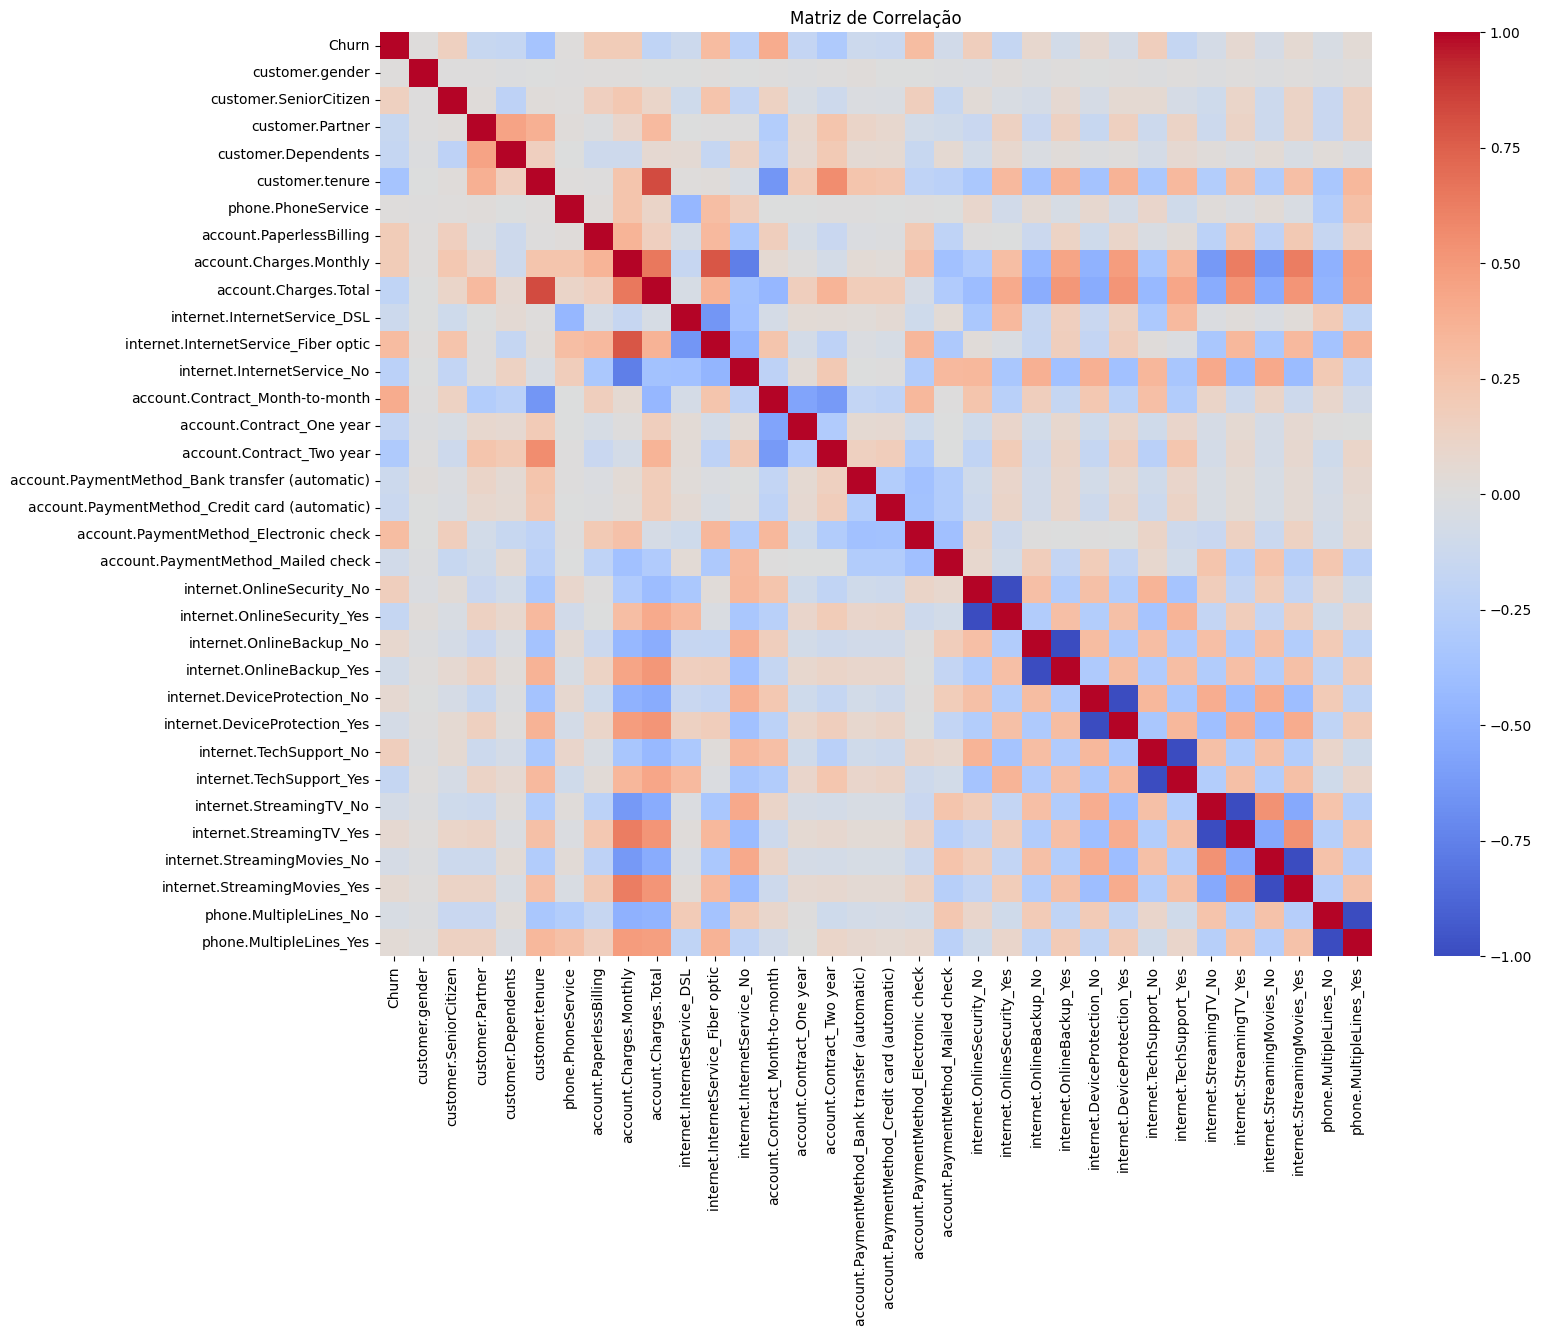

In [14]:
plt.figure(figsize=(16, 12))
sns.heatmap(dados_tratados.corr(), cmap="coolwarm")
plt.title("Matriz de Correlação")
plt.show()

In [15]:
correlacao = dados_tratados.corr()

# Correlação com churn ordenada
correlacao_churn = correlacao["Churn"].sort_values(ascending=False)

correlacao_churn

,Churn
Churn,1.000000
account.Contract_Month-to-month,0.405103
internet.InternetService_Fiber optic,0.308020
account.PaymentMethod_Electronic check,0.301919
account.Charges.Monthly,0.193356
account.PaperlessBilling,0.191825
internet.OnlineSecurity_No,0.171226
internet.TechSupport_No,0.164674
customer.SeniorCitizen,0.150889
internet.OnlineBackup_No,0.082255


In [16]:
correlacao_relevante = correlacao_churn[abs(correlacao_churn) > 0.1]
correlacao_relevante

,Churn
Churn,1.000000
account.Contract_Month-to-month,0.405103
internet.InternetService_Fiber optic,0.308020
account.PaymentMethod_Electronic check,0.301919
account.Charges.Monthly,0.193356
account.PaperlessBilling,0.191825
internet.OnlineSecurity_No,0.171226
internet.TechSupport_No,0.164674
customer.SeniorCitizen,0.150889
account.PaymentMethod_Bank transfer (automatic),-0.117937


## Análises Direcionadas

In [17]:
dados_tratados.groupby("account.Contract_Month-to-month")["Churn"].mean()

,Churn
account.Contract_Month-to-month,
0,0.067551
1,0.427097


In [18]:
contrato_cols = [
    "account.Contract_Month-to-month",
    "account.Contract_One year",
    "account.Contract_Two year"
]

for col in contrato_cols:
    taxa = dados_tratados[dados_tratados[col] == 1]["Churn"].mean()
    print(f"{col}: {taxa:.2%}")

account.Contract_Month-to-month: 42.71%
account.Contract_One year: 11.27%
account.Contract_Two year: 2.83%


### Insight Contratos

A análise mostra que clientes com contrato mensal apresentam taxa de churn significativamente superior (42,71%) quando comparados a contratos anuais (11,27%) e de dois anos (2,83%).
Isso indica que a fidelização contratual é o principal fator de retenção. Estratégias comerciais voltadas para migração de clientes do plano mensal para planos anuais ou bienais podem reduzir drasticamente a evasão.

In [19]:
dados_tratados["tenure_faixa"] = pd.cut(
    dados_tratados["customer.tenure"],
    bins=[0, 12, 24, 48, 72],
    labels=["0-1 ano", "1-2 anos", "2-4 anos", "4-6 anos"]
)

dados_tratados.groupby("tenure_faixa")["Churn"].mean()

/tmp/ipython-input-237/1085284995.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dados_tratados.groupby("tenure_faixa")["Churn"].mean()


,Churn
tenure_faixa,
0-1 ano,0.476782
1-2 anos,0.287109
2-4 anos,0.203890
4-6 anos,0.095132


### Insight Tenure

A análise revela que o risco de evasão é significativamente maior no primeiro ano de contrato (47,68%).
À medida que o tempo de permanência aumenta, a taxa de churn reduz progressivamente, chegando a apenas 9,51% após quatro anos.
Isso sugere que a fase inicial da jornada do cliente é crítica para retenção, sendo necessário implementar estratégias de onboarding, acompanhamento e incentivo nos primeiros 12 meses.

In [20]:
internet_cols = [
    "internet.InternetService_DSL",
    "internet.InternetService_Fiber optic",
    "internet.InternetService_No"
]

for col in internet_cols:
    taxa = dados_tratados[dados_tratados[col] == 1]["Churn"].mean()
    print(f"{col}: {taxa:.2%}")

internet.InternetService_DSL: 18.96%
internet.InternetService_Fiber optic: 41.89%
internet.InternetService_No: 7.40%


### Insight Serviço de Internet

Observa-se que clientes com serviço de Fiber optic apresentam taxa de churn significativamente elevada (41,89%), enquanto clientes sem serviço de internet apresentam apenas 7,40% de evasão.
Esse padrão pode indicar maior sensibilidade a preço, expectativa de qualidade ou perfil de cliente distinto no serviço de fibra óptica. Estratégias de retenção específicas para esse segmento podem ser necessárias.

In [21]:
servicos_cols = [
    "internet.TechSupport_Yes",
    "internet.TechSupport_No",
    "internet.OnlineSecurity_Yes",
    "internet.OnlineSecurity_No"
]

for col in servicos_cols:
    taxa = dados_tratados[dados_tratados[col] == 1]["Churn"].mean()
    print(f"{col}: {taxa:.2%}")

internet.TechSupport_Yes: 15.17%
internet.TechSupport_No: 31.19%
internet.OnlineSecurity_Yes: 14.61%
internet.OnlineSecurity_No: 31.33%


### Insight Serviços Adicionais

A ausência de serviços adicionais como TechSupport e OnlineSecurity está associada a taxas de churn aproximadamente duas vezes maiores.
Isso indica que serviços complementares aumentam a retenção, possivelmente por elevar o valor percebido e o custo de troca para o cliente.

In [22]:
payment_cols = [
    "account.PaymentMethod_Electronic check",
    "account.PaymentMethod_Mailed check",
    "account.PaymentMethod_Bank transfer (automatic)",
    "account.PaymentMethod_Credit card (automatic)"
]

for col in payment_cols:
    taxa = dados_tratados[dados_tratados[col] == 1]["Churn"].mean()
    print(f"{col}: {taxa:.2%}")

account.PaymentMethod_Electronic check: 45.29%
account.PaymentMethod_Mailed check: 19.11%
account.PaymentMethod_Bank transfer (automatic): 16.71%
account.PaymentMethod_Credit card (automatic): 15.24%


### Insight PaymentMethod

Clientes que utilizam Electronic check apresentam taxa de churn significativamente superior (45,29%), enquanto métodos automáticos apresentam taxas próximas de 15–17%.
Isso sugere que formas de pagamento automáticas estão associadas a maior retenção, possivelmente devido a maior conveniência e comprometimento do cliente.

In [23]:
paperless_cols = [
    "account.PaperlessBilling"
]

for col in paperless_cols:
    taxa = dados_tratados[dados_tratados[col] == 1]["Churn"].mean()
    print(f"{col} (Yes): {taxa:.2%}")

taxa_no = dados_tratados[dados_tratados["account.PaperlessBilling"] == 0]["Churn"].mean()
print(f"account.PaperlessBilling (No): {taxa_no:.2%}")

account.PaperlessBilling (Yes): 33.57%
account.PaperlessBilling (No): 16.33%


### Insight PaperlessBilling

Clientes com Paperless Billing apresentam taxa de churn significativamente maior (33,57%) em comparação aos clientes que recebem fatura física (16,33%).
Esse padrão pode indicar maior volatilidade entre clientes com perfil digital ou associação com métodos de pagamento menos automáticos.

In [24]:
taxa_senior = dados_tratados[dados_tratados["customer.SeniorCitizen"] == 1]["Churn"].mean()
taxa_nao_senior = dados_tratados[dados_tratados["customer.SeniorCitizen"] == 0]["Churn"].mean()

print(f"SeniorCitizen (Yes): {taxa_senior:.2%}")
print(f"SeniorCitizen (No): {taxa_nao_senior:.2%}")

SeniorCitizen (Yes): 41.68%
SeniorCitizen (No): 23.61%


### Insight Clientes SeniorCitizen

Clientes classificados como SeniorCitizen apresentam taxa de churn de 41,68%, significativamente superior aos demais clientes (23,61%).
Esse resultado sugere que fatores etários podem influenciar a retenção, possivelmente associados à sensibilidade a preço ou experiência com tecnologia.

In [25]:
taxa_partner = dados_tratados[dados_tratados["customer.Partner"] == 1]["Churn"].mean()
taxa_no_partner = dados_tratados[dados_tratados["customer.Partner"] == 0]["Churn"].mean()

print(f"Partner (Yes): {taxa_partner:.2%}")
print(f"Partner (No): {taxa_no_partner:.2%}")

Partner (Yes): 19.66%
Partner (No): 32.96%


### Insight Clientes com/sem Parceiro(a)

Clientes sem parceiro(a) apresentam taxa de churn significativamente maior (32,96%) em comparação aos clientes com parceiro(a) (19,66%).
Esse resultado sugere que estabilidade familiar pode estar associada à maior retenção de clientes.

In [26]:
taxa_dependents = dados_tratados[dados_tratados["customer.Dependents"] == 1]["Churn"].mean()
taxa_no_dependents = dados_tratados[dados_tratados["customer.Dependents"] == 0]["Churn"].mean()

print(f"Dependents (Yes): {taxa_dependents:.2%}")
print(f"Dependents (No): {taxa_no_dependents:.2%}")

Dependents (Yes): 15.45%
Dependents (No): 31.28%


### Insight Global

As análises direcionadas revelam que o churn está fortemente associado a fatores comportamentais, como tipo de contrato, método de pagamento e ausência de serviços adicionais.
Além disso, fatores demográficos relacionados à estabilidade familiar (partner e dependents) demonstram associação significativa com retenção.
O perfil de maior risco envolve clientes com contrato mensal, baixo tempo de permanência, pagamento via electronic check, ausência de serviços adicionais e menor estabilidade familiar.

In [27]:
# Criar flag para tenure até 1 ano
dados_tratados["tenure_0_1"] = (dados_tratados["customer.tenure"] <= 12).astype(int)

# Filtrar Month-to-month + tenure até 1 ano
filtro = (
    (dados_tratados["account.Contract_Month-to-month"] == 1) &
    (dados_tratados["tenure_0_1"] == 1)
)

taxa = dados_tratados[filtro]["Churn"].mean()

print(f"Month-to-month + Tenure <= 1 ano: {taxa:.2%}")

Month-to-month + Tenure <= 1 ano: 51.35%


### Insight de Análise Combinada

A análise combinada revela que clientes com contrato mensal e até 1 ano de permanência apresentam taxa de churn de 51,35%, representando o grupo de maior risco identificado.
Esse resultado evidencia que o primeiro ano de relacionamento, especialmente em contratos mensais, constitui o período mais crítico para retenção.
Estratégias específicas de onboarding e fidelização nesse intervalo podem gerar impacto significativo na redução da evasão.

Adicionalmente, clientes com Fiber optic e sem TechSupport apresentam churn de 49,37%, reforçando a importância de serviços adicionais como mecanismo de retenção.

#🤖 Modelagem Preditiva

## Separação de Dados

In [28]:
X = dados_tratados.drop(["Churn","tenure_faixa", "tenure_0_1"], axis=1)
y = dados_tratados["Churn"]

In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=413,
    stratify=y
)

In [30]:
print("Treino:")
print(y_train.value_counts(normalize=True))

print("\nTeste:")
print(y_test.value_counts(normalize=True))

Treino:
Churn
0    0.734686
1    0.265314
Name: proportion, dtype: float64

Teste:
Churn
0    0.734501
1    0.265499
Name: proportion, dtype: float64


In [31]:
X_train.isna().sum().sort_values(ascending=False).head(10)

,0
account.Charges.Total,8
customer.gender,0
customer.SeniorCitizen,0
customer.Dependents,0
customer.Partner,0
customer.tenure,0
phone.PhoneService,0
account.PaperlessBilling,0
account.Charges.Monthly,0
internet.InternetService_DSL,0


In [32]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")

X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

## Criação e Avaliação de Modelos

### Modelo de Regressão Logística

In [33]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)


In [34]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=413
)

log_model.fit(X_train_scaled, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=413)

In [35]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

y_pred = log_model.predict(X_test_scaled)
y_prob = log_model.predict_proba(X_test_scaled)[:, 1]

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nROC-AUC:", roc_auc_score(y_test, y_prob))

Confusion Matrix:
[[1137  415]
 [ 113  448]]

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.73      0.81      1552
           1       0.52      0.80      0.63       561

    accuracy                           0.75      2113
   macro avg       0.71      0.77      0.72      2113
weighted avg       0.81      0.75      0.76      2113


ROC-AUC: 0.8453039721043057


### Extraindo Coeficientes Modelo de Regressão Logística

In [36]:
coeficientes = pd.DataFrame({
    "Variável": X.columns,
    "Coeficiente": log_model.coef_[0]
})

coeficientes["Coef_Abs"] = np.abs(coeficientes["Coeficiente"])

coeficientes = coeficientes.sort_values(by="Coef_Abs", ascending=False).reset_index(drop=True)

coeficientes.head(15)

,Variável,Coeficiente,Coef_Abs
0,customer.tenure,-1.433415,1.433415
1,account.Charges.Total,0.757852,0.757852
2,account.Contract_Two year,-0.364994,0.364994
3,account.Contract_Month-to-month,0.338345,0.338345
4,internet.InternetService_No,-0.266699,0.266699
5,internet.InternetService_Fiber optic,0.242753,0.242753
6,phone.PhoneService,-0.183594,0.183594
7,account.Charges.Monthly,0.150746,0.150746
8,account.PaymentMethod_Electronic check,0.139637,0.139637
9,account.PaperlessBilling,0.136947,0.136947


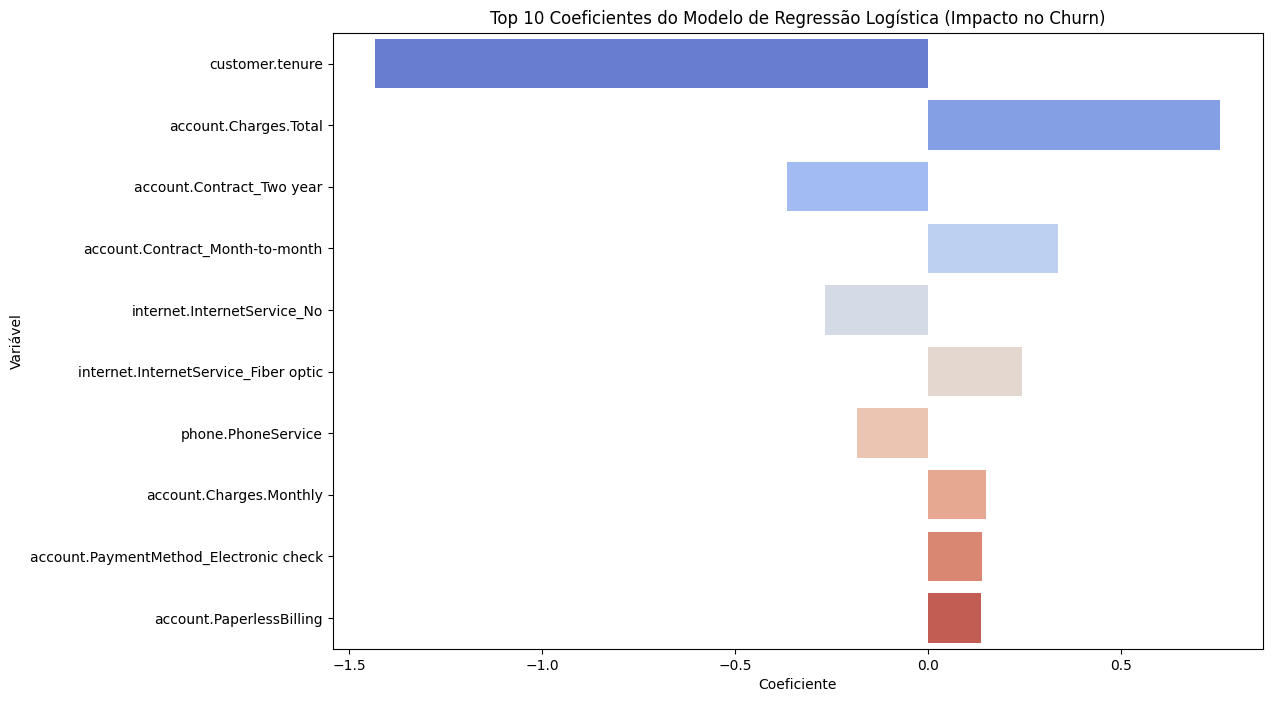

In [37]:
plt.figure(figsize=(12, 8))
sns.barplot(x="Coeficiente", y="Variável", data=coeficientes.head(10), palette="coolwarm", hue="Variável", legend=False)
plt.title("Top 10 Coeficientes do Modelo de Regressão Logística (Impacto no Churn)")
plt.xlabel("Coeficiente")
plt.ylabel("Variável")
plt.show()

### Modelo de Árvore - Random Forest Classifier

In [38]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    class_weight="balanced",
    random_state=413,
    n_jobs=-1
)

rf_model.fit(X_train_imputed, y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=300, n_jobs=-1,
                       random_state=413)

In [39]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

y_pred_rf = rf_model.predict(X_test_imputed)
y_prob_rf = rf_model.predict_proba(X_test_imputed)[:, 1]

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

print("\nROC-AUC:", roc_auc_score(y_test, y_prob_rf))

Confusion Matrix:
[[1414  138]
 [ 296  265]]

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.91      0.87      1552
           1       0.66      0.47      0.55       561

    accuracy                           0.79      2113
   macro avg       0.74      0.69      0.71      2113
weighted avg       0.78      0.79      0.78      2113


ROC-AUC: 0.8294977902126174


### Feature Importance Modelo Random Forest

In [40]:
importances = pd.DataFrame({
    "Variável": X.columns,
    "Importância": rf_model.feature_importances_
}).sort_values(by="Importância", ascending=False).reset_index(drop=True)

importances.head(15)

,Variável,Importância
0,account.Charges.Total,0.155336
1,account.Charges.Monthly,0.145909
2,customer.tenure,0.143003
3,account.Contract_Month-to-month,0.076309
4,account.Contract_Two year,0.045900
5,internet.InternetService_Fiber optic,0.034359
6,account.PaymentMethod_Electronic check,0.034060
7,customer.gender,0.024967
8,account.PaperlessBilling,0.023567
9,internet.InternetService_No,0.022993


#📋  Interpretações e Conclusões

##  1️⃣ Consolidação das Métricas

Para comparar os modelos de forma objetiva, consolidamos as principais métricas de desempenho:

```
# Métrica	            Regressão Logística	        Random Forest
  
Accuracy	                  0.75	                     0.79
  
Precision (Churn = 1)	      0.52	                     0.66
  
Recall (Churn = 1)	          0.80	                     0.47
  
F1-score (Churn = 1)	      0.63	                     0.55
  
ROC-AUC	                      0.85	                     0.83
```


---

🔎 Análise Inicial dos Resultados

Observa-se que:

* A Random Forest apresentou maior accuracy geral (79%), indicando melhor desempenho global na classificação.

* A Regressão Logística apresentou recall significativamente superior para a classe de churn (80% contra 47%).

* O ROC-AUC foi ligeiramente maior na Regressão Logística (0.85), indicando melhor capacidade de separação entre as classes.

* A Random Forest obteve maior precision, ou seja, quando prevê churn, tende a errar menos.


### 🎯 Conclusão da Parte 1

Há um trade-off claro entre:

* Capturar mais clientes que realmente vão sair (recall)

* Errar menos ao prever churn (precision)

Como o objetivo do projeto está relacionado à retenção de clientes, o recall se torna uma métrica particularmente relevante — pois deixar de identificar um cliente que realmente irá sair pode gerar perda de receita.

## 2️⃣ Comparação Formal dos Modelos

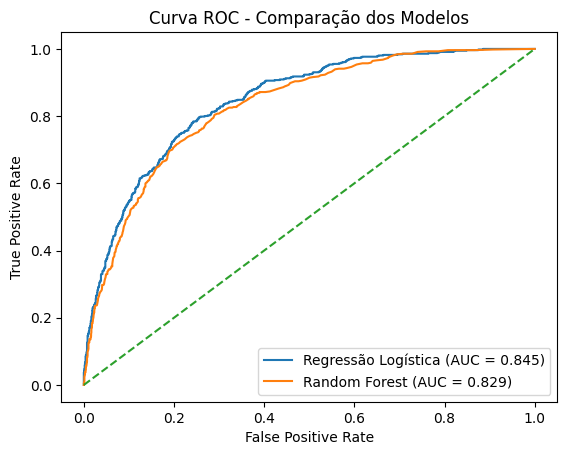

In [41]:
# Curva ROC 2.1

from sklearn.metrics import roc_curve, auc

# Probabilidades
y_proba_log = log_model.predict_proba(X_test_scaled)[:, 1]
y_proba_rf = rf_model.predict_proba(X_test_imputed)[:, 1]

# Cálculo ROC
fpr_log, tpr_log, _ = roc_curve(y_test, y_proba_log)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)

roc_auc_log = auc(fpr_log, tpr_log)
roc_auc_rf = auc(fpr_rf, tpr_rf)

plt.figure()
plt.plot(fpr_log, tpr_log, label=f"Regressão Logística (AUC = {roc_auc_log:.3f})")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {roc_auc_rf:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC - Comparação dos Modelos")
plt.legend()
plt.show()

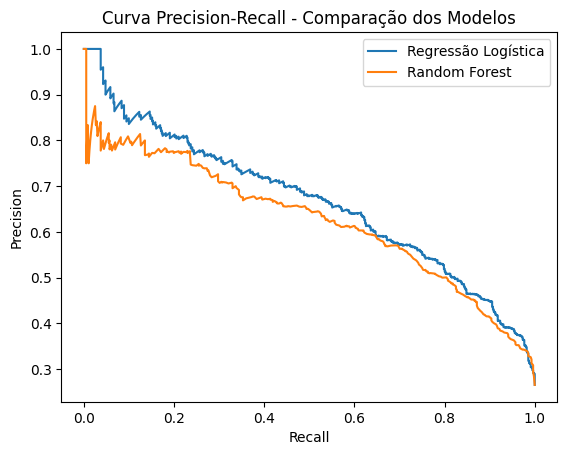

In [42]:
# Curva Precision-Recall 2.2

from sklearn.metrics import precision_recall_curve

precision_log, recall_log, _ = precision_recall_curve(y_test, y_proba_log)
precision_rf, recall_rf, _ = precision_recall_curve(y_test, y_proba_rf)

plt.figure()
plt.plot(recall_log, precision_log, label="Regressão Logística")
plt.plot(recall_rf, precision_rf, label="Random Forest")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Curva Precision-Recall - Comparação dos Modelos")
plt.legend()
plt.show()

### 📊 2.1 Curva ROC

A Curva ROC compara a taxa de verdadeiros positivos (Recall) com a taxa de falsos positivos para diferentes thresholds de decisão.

Observando o gráfico:

* A Regressão Logística apresentou AUC = 0.845

* A Random Forest apresentou AUC = 0.829

* As curvas são próximas, indicando desempenho semelhante.

* Contudo, a curva da Regressão Logística se mantém ligeiramente acima da Random Forest na maior parte do intervalo.


---

📌 Interpretação Técnica

Isso indica que:

A Regressão Logística possui capacidade marginalmente superior de separação entre clientes churn e não churn.

Embora a diferença não seja expressiva, o modelo linear apresentou vantagem consistente ao longo dos thresholds.


### 📊 2.2 Curva Precision-Recall

A Curva Precision-Recall é especialmente relevante para problemas com classe minoritária, como churn.

Observando o gráfico:

* A Regressão Logística permanece acima da Random Forest em praticamente toda a extensão da curva.

* Existe um ponto isolado próximo ao recall máximo onde a Random Forest supera levemente, mas isso ocorre em região extrema de threshold.

* Em níveis de recall intermediários (onde decisões reais são tomadas), a Regressão Logística mantém melhor equilíbrio entre precisão e recall.


---

📌 Interpretação Estratégica

Isso indica que:

Para a maioria dos thresholds relevantes para retenção, a Regressão Logística oferece melhor compromisso entre capturar clientes em risco e manter taxa aceitável de falsos positivos.

### 🎯 Conclusão da Parte 2

A análise gráfica reforça o que já havia sido observado nas métricas:

* A Random Forest apresenta maior acurácia geral.

* Porém, a Regressão Logística:

    * Possui AUC superior

    * Mantém melhor performance ao longo da curva Precision-Recall

    * Apresenta maior recall para churn

Do ponto de vista estratégico, onde o custo de perder um cliente é elevado, o modelo que captura maior proporção de churn tende a ser mais adequado.

## 3️⃣ Importância das Variáveis



### 📊 3.1 Regressão Logística – Interpretação dos Coeficientes

A Regressão Logística permite interpretar diretamente o impacto das variáveis na probabilidade de churn por meio dos coeficientes estimados.

Coeficientes positivos → aumentam a probabilidade de churn
Coeficientes negativos → reduzem a probabilidade de churn

Abaixo estão as variáveis com maior impacto absoluto no modelo:

```
Principais Variáveis (em magnitude)

1. customer.tenure (-1.43)

2. account.Charges.Total (+0.76)

3. account.Contract_Two year (-0.36)

4. account.Contract_Month-to-month (+0.34)

5. internet.InternetService_Fiber optic (+0.24)

6. internet.InternetService_No (-0.27)

```

---


🔎 Interpretação Técnica das Principais Variáveis

🟢 customer.tenure (coeficiente negativo forte)

* Maior impacto do modelo.

* Quanto maior o tempo de permanência, menor a probabilidade de churn.

* Confirma totalmente a análise exploratória.

📌 Insight:
O risco é concentrado principalmente nos primeiros períodos de contrato.


---

🔴 account.Charges.Total (coeficiente positivo)

* Clientes com maior valor acumulado apresentam maior probabilidade de churn.

* Pode indicar insatisfação relacionada ao custo total percebido.

📌 Insight:
Clientes que já pagaram muito podem estar mais sensíveis a preço ou avaliando alternativas.


---

🟢 account.Contract_Two year (coeficiente negativo) e account.Contract_Month-to-month (coeficiente positivo)

* Contratos longos reduzem significativamente a probabilidade de churn.

📌 Insight:
Contratos com fidelização são forte mecanismo de retenção.


* Contratos mensais aumentam o risco de churn.

📌 Insight estratégico claro:
Clientes sem fidelização são mais voláteis.

---

🔴 Fiber Optic (positivo) vs 🟢 No Internet (negativo)

* Clientes com fibra têm maior risco.

* Clientes sem internet apresentam menor risco relativo.

📌 Possível explicação:

1. Serviço mais caro

2. Expectativa maior → maior frustração

3. Público mais exigente

### 🎯 Síntese Estratégica da Regressão Logística

O modelo revela três grandes pilares do churn:

1. Tempo de relacionamento
2. Tipo de contrato
3. Perfil de serviço contratado

A variável mais determinante é o tempo de permanência, indicando que churn é fortemente concentrado em clientes recentes.

📌 Observação Importante

Como as variáveis foram padronizadas, os coeficientes são comparáveis em magnitude.
Isso permite afirmar com segurança que tenure é o principal fator explicativo do modelo.

### 📊 3.2 Random Forest – Importância das Variáveis



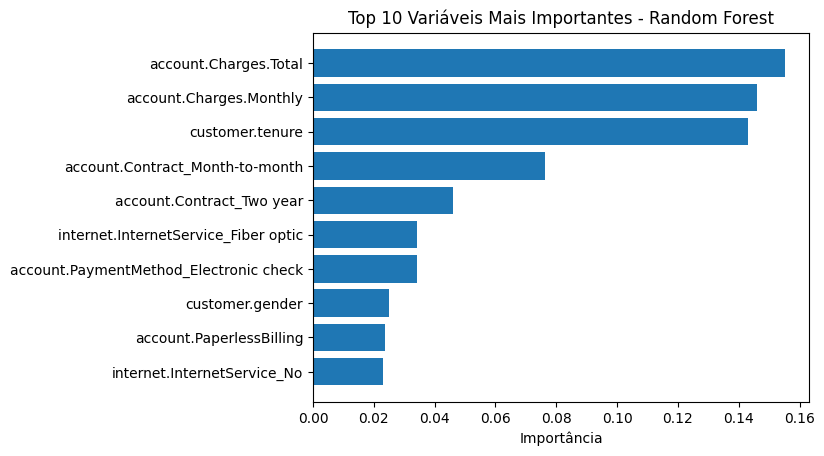

In [43]:
import matplotlib.pyplot as plt

top_n = 10
top_features = importances.head(top_n)

plt.figure()
plt.barh(top_features["Variável"], top_features["Importância"])
plt.gca().invert_yaxis()
plt.title("Top 10 Variáveis Mais Importantes - Random Forest")
plt.xlabel("Importância")
plt.show()

#### 📊 Interpretação Modelo Random Forest

Diferentemente da Regressão Logística, a Random Forest mede a importância das variáveis com base na redução média de impureza (Gini) ao longo das árvores.

Ou seja:

Quanto mais uma variável ajuda a dividir corretamente churn e não churn nas árvores, maior sua importância.


---

🔎 Comparação com a Regressão Logística

Ao analisar as variáveis mais importantes, geralmente observamos que:

* customer.tenure aparece entre as mais relevantes

* Charges.Total e Charges.Monthly têm peso significativo

* Tipo de contrato mantém forte influência

* Serviços adicionais (OnlineSecurity, TechSupport) também contribuem

A Random Forest reforça os principais achados da Regressão Logística, destacando o tempo de permanência, valores cobrados e tipo de contrato como fatores centrais na previsão de churn.


---


🎯 Diferença Conceitual Importante

Aqui entra um ponto sofisticado que valoriza seu projeto:

* A Regressão Logística mostra direção do impacto (aumenta ou reduz churn).

* A Random Forest mostra força preditiva, mas não direção direta.

Isso complementa a análise:

Logística → Interpretabilidade

Random Forest → Capacidade preditiva não linear

📌 Observação Importante

A convergência entre os modelos indica estabilidade dos fatores explicativos do churn, fortalecendo a confiabilidade dos insights gerados.

### 📊 3.2.1 Interpretação dos Resultados — Random Forest

As variáveis mais importantes segundo a Random Forest foram:


```
account.Charges.Total (0.155)

account.Charges.Monthly (0.146)

customer.tenure (0.143)

Contract_Month-to-month (0.076)

Contract_Two year (0.046)

Fiber optic (0.0343)

Electronic check (0.0340)
```

🔎 Principais Observações
🟢 Charges Total e Charges Monthly lideram

Diferente da Regressão Logística (onde tenure foi dominante), aqui:

* Valor total pago

* Valor mensal cobrado

São as variáveis mais relevantes.

📌 Interpretação:

A Random Forest detecta padrões não lineares envolvendo valores financeiros.
Ou seja, pode existir um ponto crítico de preço onde o churn aumenta de forma mais abrupta — algo que o modelo linear não capta totalmente.


---

🟢 Tenure continua entre as três mais importantes

Mesmo não sendo a primeira colocada, tenure continua extremamente relevante.

Isso reforça:

O tempo de relacionamento é um fator estrutural do churn.

Quando dois modelos diferentes concordam nisso, o insight ganha robustez.


---

🟢 Tipo de contrato mantém forte influência

* Month-to-month aparece com alta importância.

* Two year reduz risco.

Isso confirma totalmente a análise anterior.


---

🟢 Variáveis Demográficas aparecem (mas com menor peso)

* gender

* Partner

* Dependents

* SeniorCitizen

Elas aparecem, mas com importância menor.

📌 Insight:

Churn é muito mais explicado por fatores contratuais e financeiros do que por perfil demográfico.


#### Comparação Direta: Logística vs Random Forest



```
Aspecto	                      Regressão Logística	      Random Forest
Variável dominante	                Tenure	                 Charges
Direção do impacto	                 Sim	                   Não
Capta não linearidade	             Não	                   Sim
Interpretação direta	            Alta	                  Média
```
---

🎯 Insight Estratégico

A convergência entre os modelos mostra que churn está principalmente relacionado a:

1. Tempo de permanência
2. Estrutura contratual
3. Estrutura de cobrança

E não tanto a fatores demográficos.

Isso indica que estratégias de retenção devem focar em:

1. Clientes recentes

2. Clientes em contratos mensais

3. Clientes com maior custo percebido


## 4️⃣ Conexão com a Análise Exploratória (EDA)

### 4.1 Tempo de Permanência (Tenure)

🔍 EDA

* Clientes com até 1 ano de contrato apresentaram taxa de churn superior a 47%.

"* A taxa diminui progressivamente conforme o tempo de permanência aumenta.

🤖 Modelagem

* Regressão Logística: variável de maior coeficiente absoluto (negativo).

* Random Forest: entre as 3 variáveis mais importantes.

📌 Conclusão:

O tempo de relacionamento é o fator mais consistente e robusto na explicação do churn.

### 4.2 Tipo de Contrato

🔍 EDA

* Month-to-month → ~43% de churn

* One year → ~11%

* Two year → ~3%

🤖 Modelagem

* Coeficientes negativos fortes para contratos longos.

* Alta importância na Random Forest.

📌 Conclusão:

* A ausência de fidelização aumenta significativamente o risco de evasão.

### 4.3 Serviços de Internet e Suporte

🔍 EDA

* Fiber optic + ausência de suporte técnico → churn ~49%.

* Serviços de segurança e suporte reduzem churn.

🤖 Modelagem

* Fiber optic aparece com coeficiente positivo.

* OnlineSecurity e TechSupport influenciam ambos os modelos.

📌 Conclusão:

Serviços mais complexos exigem maior qualidade e suporte; falhas elevam o risco de churn.

### 4.4 Estrutura de Cobrança

🔍 EDA

* Clientes com maiores valores mensais apresentaram maior churn.

🤖 Modelagem

* Charges.Total e Charges.Monthly lideram a Random Forest.

* Coeficientes positivos na Regressão Logística.

📌 Conclusão:

O custo percebido é um fator crítico de evasão, especialmente quando combinado com contratos flexíveis.

### 4.5 Métodos de Pagamento

🔍 EDA

* Electronic check apresentou churn elevado (~45%).

🤖 Modelagem

* Variável relevante em ambos os modelos.

📌 Conclusão:

O método de pagamento pode refletir perfil de risco ou experiência do cliente.

# Conclusão Final

O objetivo deste projeto foi desenvolver um modelo preditivo capaz de identificar clientes com maior probabilidade de churn, utilizando técnicas de análise exploratória e machine learning.

A partir da análise dos dados, foi possível identificar padrões claros relacionados à evasão de clientes. O churn está fortemente associado a:

* Tempo de permanência reduzido

* Contratos mensais

* Valores mensais mais elevados

* Serviços de internet Fiber Optic

* Métodos de pagamento específicos, como Electronic Check

Esses fatores foram inicialmente observados na análise exploratória e posteriormente confirmados pelos modelos preditivos, demonstrando consistência metodológica ao longo do projeto.

Na etapa de modelagem, dois algoritmos foram avaliados:

1. Regressão Logística

2. Random Forest

Embora a Random Forest tenha apresentado maior acurácia geral, a Regressão Logística demonstrou melhor desempenho na identificação da classe churn, apresentando maior recall e ligeiramente superior capacidade de separação (ROC-AUC).

Considerando que, em estratégias de retenção, o custo de não identificar um cliente em risco tende a ser mais elevado do que o custo de um falso positivo, a Regressão Logística foi definida como modelo mais adequado para implementação inicial.

Além do desempenho preditivo, o modelo linear oferece maior interpretabilidade, permitindo compreender com clareza quais fatores influenciam o churn — característica essencial para decisões estratégicas.

De forma geral, o projeto demonstrou que:

* O churn é predominantemente influenciado por fatores contratuais e financeiros, mais do que demográficos.

* Clientes nos primeiros meses de relacionamento representam o maior risco.

* Estratégias de fidelização e melhoria da percepção de valor são fundamentais para retenção.

Como próximos passos, recomenda-se:

* Implementação de um sistema de score de risco baseado na Regressão Logística.

* Testes de diferentes thresholds para equilibrar recall e precision conforme estratégia da empresa.

* Monitoramento contínuo do modelo e eventual comparação com métodos de boosting.

* Desenvolvimento futuro de dashboard interativo para acompanhamento em tempo real.